# Plotting and Visualization

In [1]:
import numpy as np
import pandas as pd
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
import matplotlib
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

%matplotlib notebook

## A Brief matplotlib API Primer

In [2]:
import matplotlib.pyplot as plt

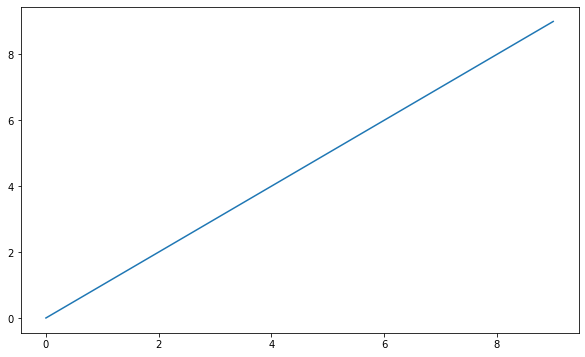

In [3]:
import numpy as np
data = np.arange(10)
data
plt.plot(data)

In [4]:
%matplotlib notebook

<IPython.core.display.Javascript object>


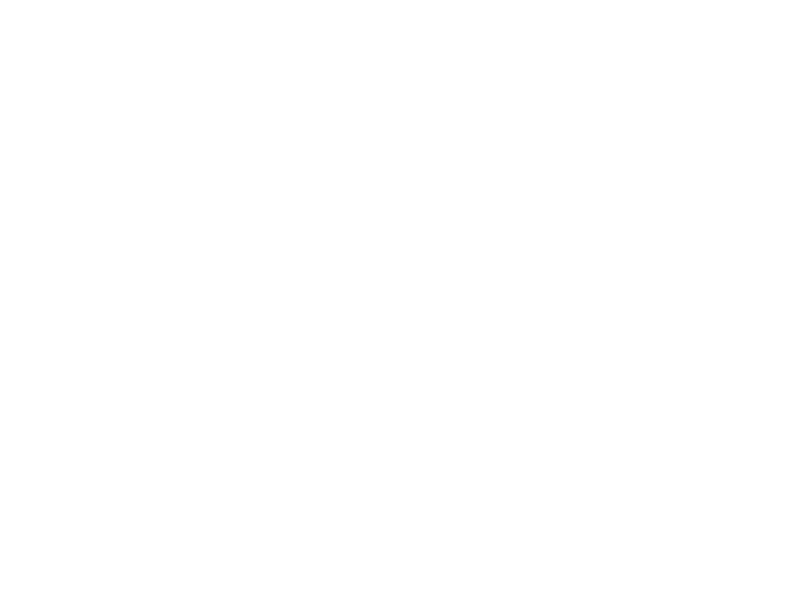

In [5]:
import numpy as np
data = np.arange(10)
data
plt.plot(data)

While libraries like seaborn and pandas’s built-in plotting functions will deal with
many of the mundane details of making plots, should you wish to customize them
beyond the function options provided, you will need to learn a bit about the **matplotlib
API.**

### Figures and Subplots

Plots in matplotlib reside within a Figure object. You can create a new figure with
`plt.figure`:

<IPython.core.display.Javascript object>


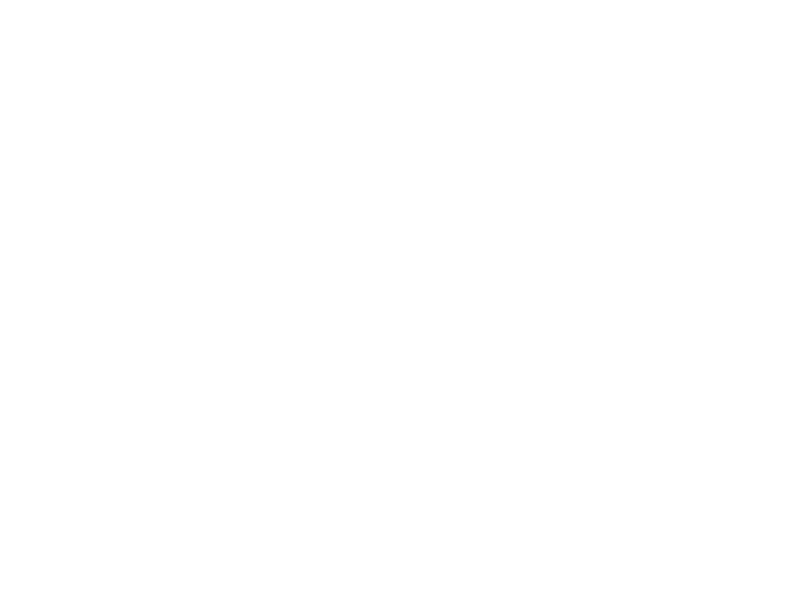

In [6]:
fig = plt.figure()

In [7]:
ax1 = fig.add_subplot(2, 2, 1)

In [8]:
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

<IPython.core.display.Javascript object>


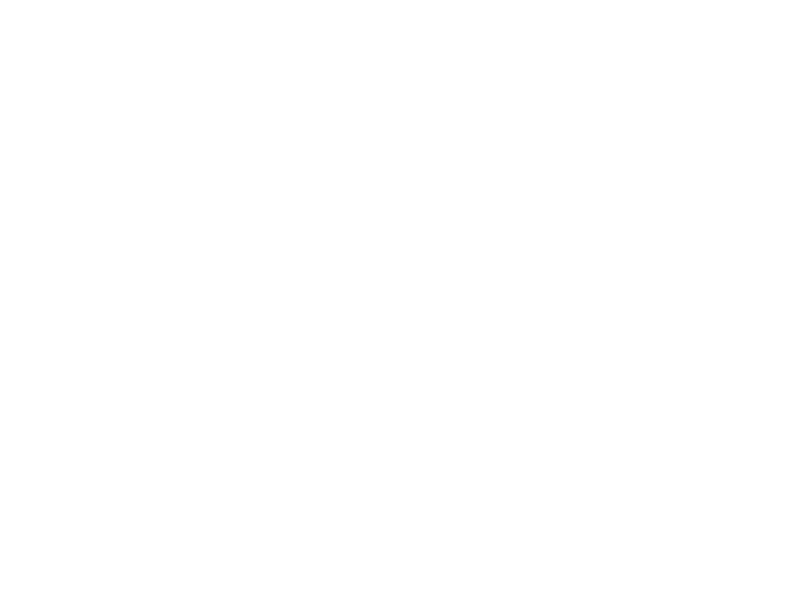

In [9]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

When you issue a plotting command like plt.plot([1.5, 3.5, -2, 1.6]), matplotlib
draws on **the last figure and subplot used** (creating one if necessary), thus hiding
the figure and subplot creation. So if we add the following command, you’ll get
something like Figure 9-3:

In [10]:
plt.plot(np.random.randn(50).cumsum(), 'k--')

The `'k--'` is a style option instructing matplotlib to plot a black dashed line. The
objects returned by `fig.add_subplot` here are `AxesSubplot` objects, on which you
can directly plot on the other empty subplots by calling each one’s instance method

In [11]:
_ = ax1.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))

In [12]:
plt.close('all')

Creating a figure with a grid of subplots is a very common task, so matplotlib
includes a convenience method, `plt.subplots`, that creates a new figure and returns
a NumPy array containing the created **subplot objects**:

<IPython.core.display.Javascript object>


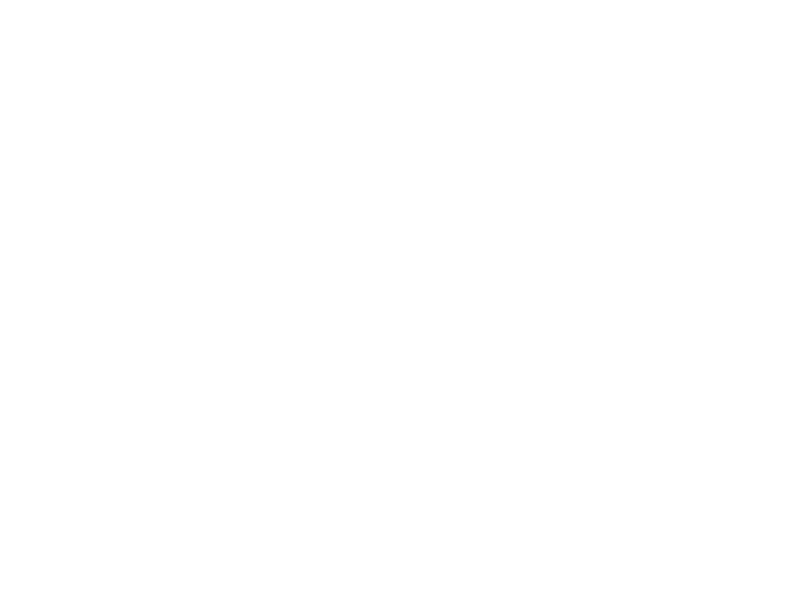

array([[<AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>]], dtype=object)

In [13]:
fig, axes = plt.subplots(2, 2, sharex=True)
axes

In [14]:
#ลองเอง # ทำให้ได้ผลลัพธ์เหมือน plot อันก่อนหน้า
axes[0, 0].hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
axes[0, 1].scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))
axes[1, 0].plot(np.random.randn(50).cumsum(), 'k--')

![](chan_folder/subplots.png)

#### Adjusting the spacing around subplots

By default matplotlib leaves a certain amount of padding around the outside of the
subplots and spacing between subplots. This spacing is all specified relative to the
height and width of the plot, so that if you resize the plot either programmatically or
manually using the GUI window, the plot will dynamically adjust itself. You can
change the spacing using the `subplots_adjust` method on Figure objects, also available
as a top-level function:

subplots_adjust(left=None, bottom=None, right=None, top=None,
                wspace=None, hspace=None)

`wspace` and `hspace` controls the percent of the figure width and figure height, respectively,
to use as spacing between subplots. Here is a small example where I shrink the
spacing all the way to zero (see Figure 9-5):

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

<IPython.core.display.Javascript object>


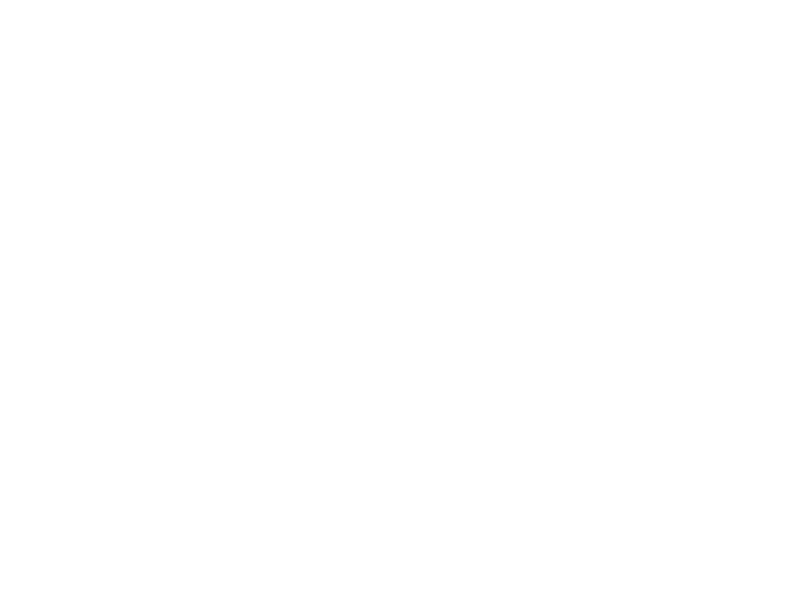

In [15]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)

In [16]:
plt.subplots_adjust(wspace=0, hspace=0)
#plt.subplots_adjust(wspace=0.5, hspace=0.5)
#plt.subplots_adjust(wspace=1, hspace=1)

You may notice that the axis labels overlap. matplotlib doesn’t check whether the
labels overlap, so in a case like this you would need to fix the labels yourself by specifying
**explicit tick locations and tick labels** (we’ll look at how to do this in the following
sections).

### Colors, Markers, and Line Styles

ax.plot(x, y, 'g--')

ax.plot(x, y, linestyle='--', color='g')

In [17]:
ax1.plot?

<IPython.core.display.Javascript object>


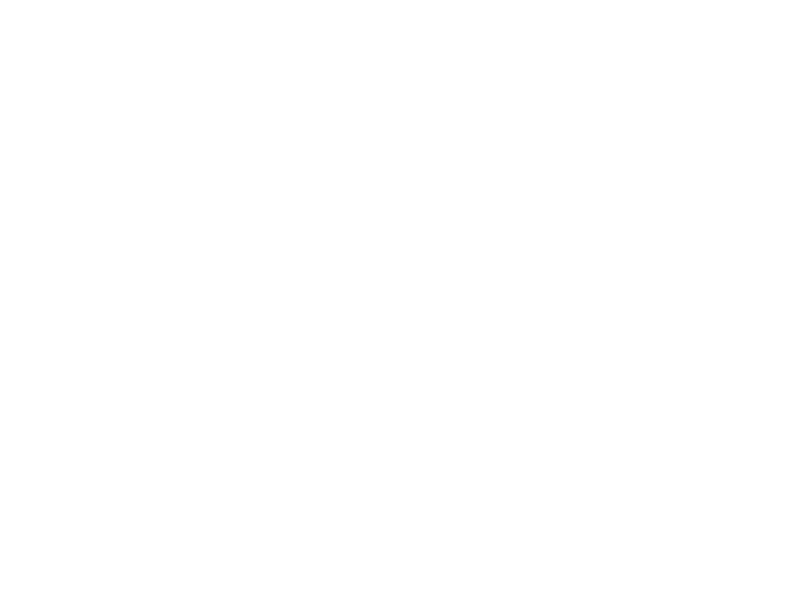

In [18]:
my_fig = plt.figure()

In [19]:
from numpy.random import randn
my_ax1 = my_fig.add_subplot(2,1,1)
my_ax2 = my_fig.add_subplot(2,1,2)


In [20]:
my_ax1.clear(); my_ax2.clear()
my_ax1.plot(randn(30).cumsum(), 'ko--')
my_ax2.plot(randn(30).cumsum(), 'bD-.')

plot(randn(30).cumsum(), color='k', linestyle='dashed', marker='o')

In [21]:
plt.close('all')

<IPython.core.display.Javascript object>


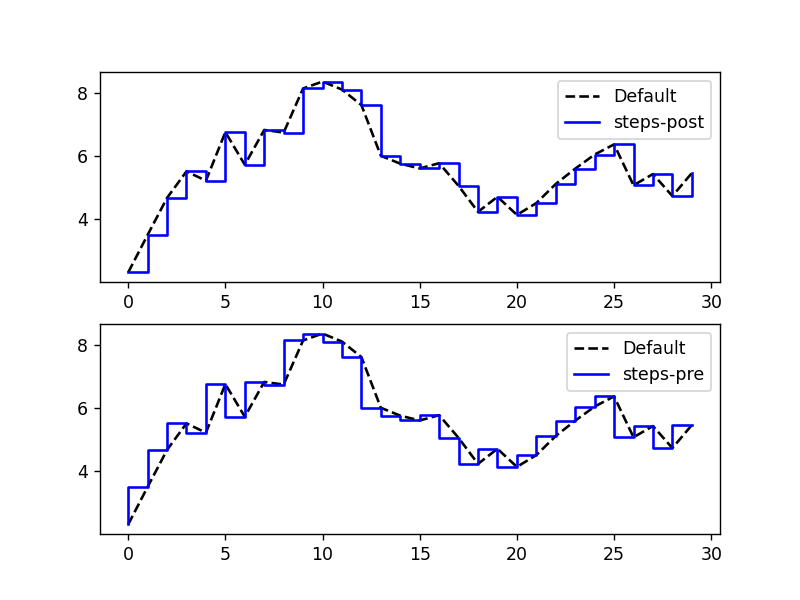

In [22]:
data = np.random.randn(30).cumsum()
her_fig, her_axes = plt.subplots(2, 1)

In [23]:
#post #pre
her_axes[0].clear(); 
her_axes[1].clear()

# เอาค่าที่่ f(5) ไป fill ในตำแหน่งหลังจาก 5
her_axes[0].plot(data, 'k--', label='Default')
her_axes[0].plot(data, 'b-', drawstyle='steps-post', label='steps-post')
her_axes[0].legend(loc='best')

# เอาค่าที่่ f(5) ไป fill ในตำแหน่งก่อนถึง 5
her_axes[1].plot(data, 'k--', label='Default')
her_axes[1].plot(data, 'b-', drawstyle='steps-pre', label='steps-pre')
her_axes[1].legend(loc='best')

# from book
# plt.legend(loc='best')

Here, since we passed the `label`
arguments to `plot`, we are able to create a plot legend to identify each line using
`plt.legend`.


>You must call plt.legend (or ax.legend, if you have a reference to
the axes) to create the legend, whether or not you passed the label
options when plotting the data.

### Ticks, Labels, and Legends

For most kinds of plot decorations, there are two main ways to do things: using the
procedural `pyplot` interface (i.e., `matplotlib.pyplot`) and the more object-oriented
native matplotlib API.

The pyplot interface, designed for interactive use, consists of methods like `xlim,
xticks, and xticklabels`. These control the plot range, tick locations, and tick labels,
respectively. They can be used in two ways:
- Called with no arguments returns the current parameter value (e.g., `plt.xlim()`
returns the current x-axis plotting range)
- Called with parameters sets the parameter value (e.g., `plt.xlim([0, 10]`), sets
the x-axis range to 0 to 10)



All such methods act on the active or most recently created `AxesSubplot`. Each of
them corresponds to two methods on the subplot object itself; in the case of `xlim`
these are `ax.get_xlim` and `ax.set_xlim`. I prefer to use the subplot instance methods
myself in the interest of being explicit (and especially when working with multiple
subplots), but you can certainly use whichever you find more convenient.


#### Setting the title, axis labels, ticks, and ticklabels

<IPython.core.display.Javascript object>


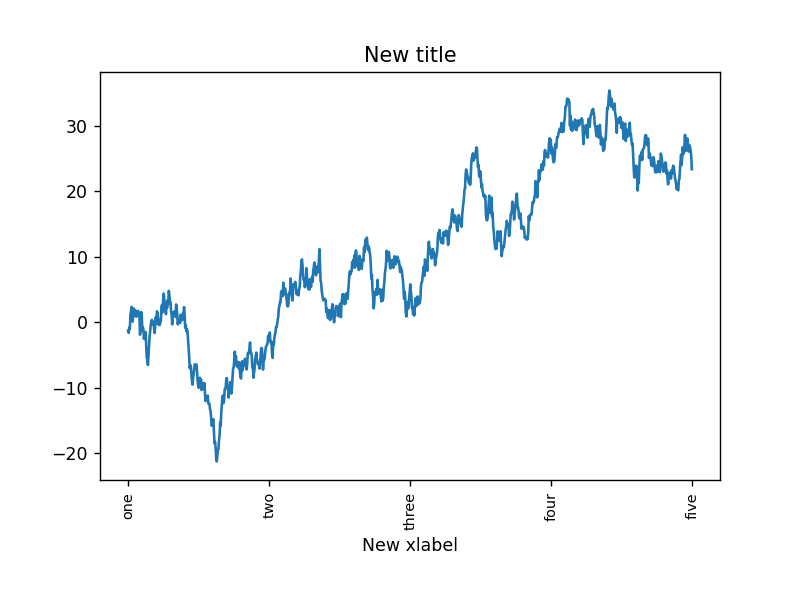

In [24]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())

In [25]:
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=90, fontsize='small') # 90 ่คือองศาของ tick labels

In [26]:
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')

Text(0.5, 0, 'Stages')

In [27]:
#ลองเอง #make_room
# to make room for the x-axis labels.
# ตอนแรก x-axis label ตกขอบด้าน่ล่างของรูป พอใช้ subplots_adjust ก็แก้ไขได้
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=None, hspace=None)

In [28]:
props = {
    'title': 'New title',
    'xlabel': 'New xlabel'
}
ax.set(**props)

[Text(0.5, 1.0, 'New title'), Text(0.5, 0, 'New xlabel')]

#### Adding legends

<IPython.core.display.Javascript object>


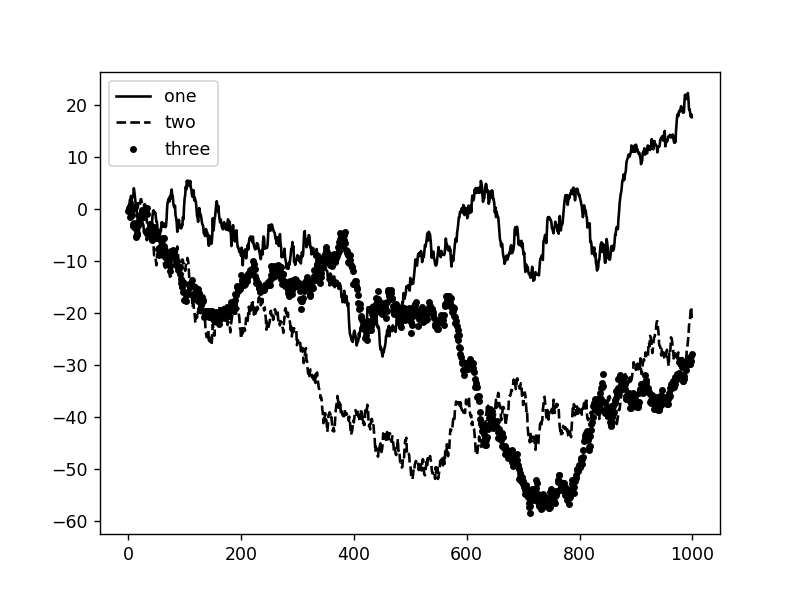

In [29]:
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'k--', label='two')
ax.plot(randn(1000).cumsum(), 'k.', label='three')

Once you’ve done this, you can either call `ax.legend()` or `plt.legend()` to automatically
create a legend.

In [30]:
ax.legend(loc='best')

### Annotations and Drawing on a Subplot

ax.text(x, y, 'Hello world!',
        family='monospace', fontsize=10)

In [ ]:
from datetime import datetime

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

data = pd.read_csv('examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']

spx.plot(ax=ax, style='k-')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of bull market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2,
                                headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom in on 2007-2010
ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])

ax.set_title('Important dates in the 2008-2009 financial crisis')

In [ ]:
ax.set_title('Important dates in the 2008–2009 financial crisis')

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

In [ ]:
fig = plt.figure(figsize=(12, 6)); ax = fig.add_subplot(1, 1, 1)
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving Plots to File

plt.savefig('figpath.svg')

plt.savefig('figpath.png', dpi=400, bbox_inches='tight')

from io import BytesIO
buffer = BytesIO()
plt.savefig(buffer)
plot_data = buffer.getvalue()

### matplotlib Configuration

plt.rc('figure', figsize=(10, 10))

font_options = {'family' : 'monospace',
                'weight' : 'bold',
                'size'   : 'small'}
plt.rc('font', **font_options)

## Plotting with pandas and seaborn

### Line Plots

In [ ]:
plt.close('all')

In [ ]:
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

In [ ]:
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))
df.plot()

### Bar Plots

In [ ]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='k', alpha=0.7)
data.plot.barh(ax=axes[1], color='k', alpha=0.7)

In [ ]:
np.random.seed(12348)

In [ ]:
df = pd.DataFrame(np.random.rand(6, 4),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df
df.plot.bar()

In [ ]:
plt.figure()

In [ ]:
df.plot.barh(stacked=True, alpha=0.5)

In [ ]:
plt.close('all')

In [ ]:
tips = pd.read_csv('examples/tips.csv')
party_counts = pd.crosstab(tips['day'], tips['size'])
party_counts
# Not many 1- and 6-person parties
party_counts = party_counts.loc[:, 2:5]

In [ ]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(1), axis=0)
party_pcts
party_pcts.plot.bar()

In [ ]:
plt.close('all')

In [ ]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips.head()
sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

In [ ]:
plt.close('all')

In [ ]:
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

In [ ]:
plt.close('all')

In [ ]:
sns.set(style="whitegrid")

### Histograms and Density Plots

In [ ]:
plt.figure()

In [ ]:
tips['tip_pct'].plot.hist(bins=50)

In [ ]:
plt.figure()

In [ ]:
tips['tip_pct'].plot.density()

In [ ]:
plt.figure()

In [ ]:
comp1 = np.random.normal(0, 1, size=200)
comp2 = np.random.normal(10, 2, size=200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.distplot(values, bins=100, color='k')

### Scatter or Point Plots

In [ ]:
macro = pd.read_csv('examples/macrodata.csv')
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data[-5:]

In [ ]:
plt.figure()

In [ ]:
sns.regplot('m1', 'unemp', data=trans_data)
plt.title('Changes in log %s versus log %s' % ('m1', 'unemp'))

In [ ]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha': 0.2})

### Facet Grids and Categorical Data

In [ ]:
sns.factorplot(x='day', y='tip_pct', hue='time', col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

In [ ]:
sns.factorplot(x='day', y='tip_pct', row='time',
               col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

In [ ]:
sns.factorplot(x='tip_pct', y='day', kind='box',
               data=tips[tips.tip_pct < 0.5])

## Other Python Visualization Tools

In [ ]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS

## Conclusion